# 亚马逊评论情感分析 — 序列 + 经典 + 集成 + 代价矩阵 + LLM 错误分析

本周三大任务：
1. **代价矩阵 (Task 1)** — 漏判差评 (FN) 与误判好评 (FP) 的代价比设为 **5 : 1**（Elkan, 2001 *The Foundations of Cost-Sensitive Learning*, IJCAI-01）。把 cost matrix 同时落到 (a) 神经网络的 `CrossEntropyLoss(weight=...)`，(b) sklearn 的 `class_weight`，(c) Optuna 优化目标，(d) 推理阶段的最优阈值，并打印每个模型的最终总 cost。
2. **集成学习 (Task 2)** — 4 个序列模型（MeanPooling / LSTM / Transformer / TextCNN）+ 5 个非序列经典模型（NB / LR / LinearSVM / LightGBM / XGBoost），用 **5-fold OOF stacking** 把两类特征互补地组合起来。
3. **错误分析深化 (Task 3)** — 把模型与真实标签不一致的争议样本喂给 LLM，验证是否存在标注错误。

所有重型逻辑都已经放进 `src/` 目录；本 notebook 仅做调用、展示与出图。

## §1 环境设置

In [12]:
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import sys
from pathlib import Path

# 让 src 包可被 import
sys.path.insert(0, str(Path.cwd()))

%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from src import config, utils, data, cost, evaluate, stopwords
from src import preprocess_classic, preprocess_seq, vectorizer
from src import models_classic, train_classic
from src import models_seq, train_seq
from src import ensemble, error_analysis, viz
from src import llm_judge

utils.seed_everything(config.SEED)
utils.setup_matplotlib_chinese()
utils.print_compute_summary()
print(f"USE_FULL_DATA={config.USE_FULL_DATA}  DATA_FRACTION={config.DATA_FRACTION}")
print(f"COST: {config.COST_RATIO_DESC}  (FN={config.COST_FN}, FP={config.COST_FP})")
print(f"K_FOLD={config.K_FOLD}  OPTUNA_TRIALS={config.OPTUNA_TRIALS}  EPOCHS={config.EPOCHS}")
print(f"LLM_BACKEND={config.LLM_BACKEND}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[device] using: cuda
[device] mps_built=False mps_avail=False cuda_avail=True
[classic trees] CLASSIC_TREE_DEVICE=auto  XGBoost=cuda  LightGBM=cpu  (set LIGHTGBM_USE_CUDA=1 for pip+GPU LGBM build)
[seq dataloader] BATCH_SIZE=512  num_workers=4  pin_memory=True  AMP=True
USE_FULL_DATA=False  DATA_FRACTION=0.02
COST: C_FN : C_FP = 5 : 1  (Elkan 2001, IJCAI-01)  (FN=5.0, FP=1.0)
K_FOLD=3  OPTUNA_TRIALS=15  EPOCHS=5
LLM_BACKEND=stub


## §2 加载数据 & EDA

`__label__1 → 1 (差评，业务正类)`，`__label__2 → 0 (好评)`。

训练集大小: 72,000 / 全量 3,600,000
测试集大小: 8,000 / 全量 400,000
训练集标签分布: Counter({1: 36000, 0: 36000})
测试集标签分布: Counter({0: 4000, 1: 4000})
  fig -> /root/autodl-tmp/5.12/outputs/figures/label_distribution_train.png


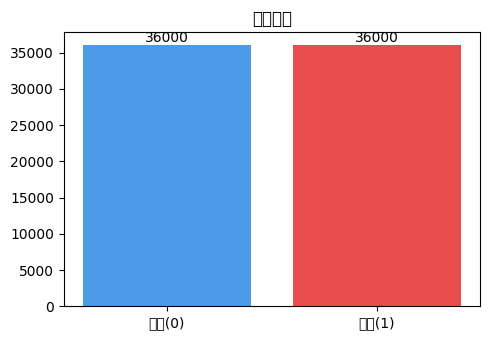

  fig -> /root/autodl-tmp/5.12/outputs/figures/label_distribution_test.png


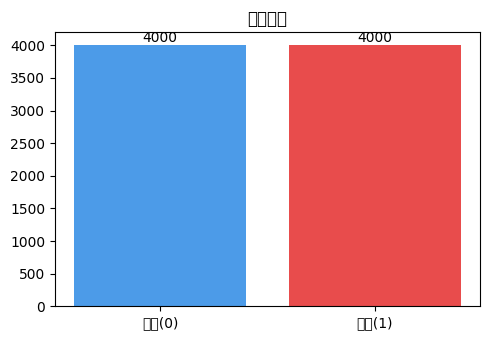

In [13]:
train_texts, train_labels, test_texts, test_labels = data.load_train_test()
viz.plot_label_distribution(train_labels, name="label_distribution_train.png")
viz.plot_label_distribution(test_labels, name="label_distribution_test.png")

句长 mean=80.4  median=72  max=219  ≤MAX_LEN(150)覆盖率=90.8%
  fig -> /root/autodl-tmp/5.12/outputs/figures/length_distribution.png


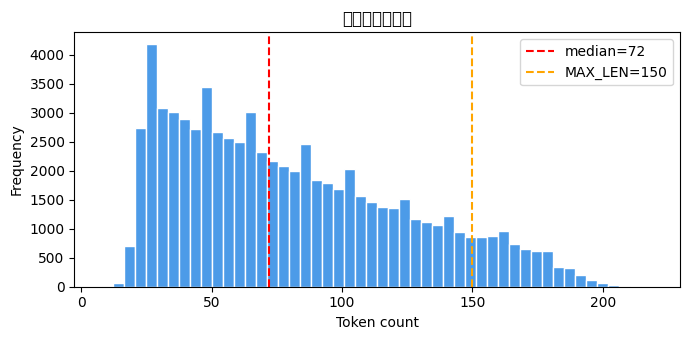

In [14]:
import re

def _quick_token_count(t):
    return len(re.findall(r"[a-z]+", t.lower()))

lengths = [_quick_token_count(t) for t in train_texts]
print(f"句长 mean={np.mean(lengths):.1f}  median={np.median(lengths):.0f}  "
      f"max={max(lengths)}  ≤MAX_LEN({config.MAX_LEN})覆盖率="
      f"{np.mean([l <= config.MAX_LEN for l in lengths]) * 100:.1f}%")
viz.plot_length_hist(lengths, max_len=config.MAX_LEN)

## §3 经典通道：三层停用词 + TF-IDF

**停用词三层：** ① NLTK + 人工扩展 → ② 数据驱动 ratio 词 → ③ 数据驱动 domain 词（MI∩χ²∩VADER 中性）。

In [15]:
import joblib

base_sw = stopwords.base_stopwords()
print(f"NLTK + 人工扩展 stopwords: {len(base_sw)}")

# 用基础停用词预处理 train，作为 ratio / domain 计算的输入
clean_train_basic = preprocess_classic.preprocess_corpus(
    train_texts, stopwords=base_sw, do_lemma=True, desc="basic-stopword"
)

ratio_sw, ratios, totals = stopwords.compute_ratio_stopwords(
    clean_train_basic, train_labels,
    cache_path=config.MODEL_DIR / "ratio_stopwords.joblib",
)
print(f"Ratio 中性词: {len(ratio_sw)}  样例: {list(ratio_sw)[:10]}")

domain_sw = stopwords.compute_domain_stopwords(
    clean_train_basic, train_labels,
    cache_path=config.MODEL_DIR / "domain_stopwords.joblib",
)
print(f"Domain 中性词: {len(domain_sw)}  样例: {list(domain_sw)[:10]}")

full_sw = stopwords.union_stopwords(base_sw, ratio_sw, domain_sw)
print(f"完整停用词集合: {len(full_sw)}")

NLTK + 人工扩展 stopwords: 258
  [basic-stopword] 7,200/72,000
  [basic-stopword] 14,400/72,000
  [basic-stopword] 21,600/72,000
  [basic-stopword] 28,800/72,000
  [basic-stopword] 36,000/72,000
  [basic-stopword] 43,200/72,000
  [basic-stopword] 50,400/72,000
  [basic-stopword] 57,600/72,000
  [basic-stopword] 64,800/72,000
  [basic-stopword] 72,000/72,000
Ratio 中性词: 1000  样例: ['pet', 'strip', 'done', 'install', 'vehicle', 'full', 'earth', 'date', 'he', 'flick']
Domain 中性词: 441  样例: ['cage', 'meantime', 'dose', 'overnight', 'pet', 'maintenance', 'pair', 'overtone', 'hisher', 'eliminate']
完整停用词集合: 1620


In [16]:
clean_train = preprocess_classic.preprocess_corpus(
    train_texts, stopwords=full_sw, do_lemma=True, desc="train-full-sw"
)
clean_test = preprocess_classic.preprocess_corpus(
    test_texts, stopwords=full_sw, do_lemma=True, desc="test-full-sw"
)

tfidf_params = vectorizer.tune_tfidf(
    clean_train, train_labels,
    n_trials=config.OPTUNA_TRIALS,
    cache_path=config.MODEL_DIR / "tfidf_best_params.joblib",
)
tfidf_keys = {k: tfidf_params[k] for k in
              ("max_features", "ngram_max", "min_df", "sublinear_tf") if k in tfidf_params}
tfidf_vec = vectorizer.build_tfidf(tfidf_keys)
X_train = tfidf_vec.fit_transform(clean_train)
X_test = tfidf_vec.transform(clean_test)
joblib.dump(tfidf_vec, config.MODEL_DIR / "tfidf_vectorizer.joblib")
print(f"X_train={X_train.shape}  X_test={X_test.shape}  TFIDF={tfidf_keys}")

  [train-full-sw] 7,200/72,000
  [train-full-sw] 14,400/72,000
  [train-full-sw] 21,600/72,000
  [train-full-sw] 28,800/72,000
  [train-full-sw] 36,000/72,000
  [train-full-sw] 43,200/72,000
  [train-full-sw] 50,400/72,000
  [train-full-sw] 57,600/72,000
  [train-full-sw] 64,800/72,000
  [train-full-sw] 72,000/72,000
  [test-full-sw] 800/8,000
  [test-full-sw] 1,600/8,000
  [test-full-sw] 2,400/8,000
  [test-full-sw] 3,200/8,000
  [test-full-sw] 4,000/8,000
  [test-full-sw] 4,800/8,000
  [test-full-sw] 5,600/8,000
  [test-full-sw] 6,400/8,000
  [test-full-sw] 7,200/8,000
  [test-full-sw] 8,000/8,000
X_train=(72000, 9000)  X_test=(8000, 9000)  TFIDF={'max_features': 9000, 'ngram_max': 2, 'min_df': 4, 'sublinear_tf': True}


## §4 训练 5 个非序列模型（Optuna 双目标：F1 vs 总 cost）

为了直接对比"F1 调参 + class_weight 加权"和"直接以代价为优化目标"两条路径，
对 LR / SVM / LightGBM / XGBoost 各跑两次 Optuna：

- `objective="f1"` — 沿用原项目的差评 F1 最大化
- `objective="cost"` — 直接最小化总 cost (`5*FN + 1*FP`)

NB 不调参（保持基线），但 fit 时通过 `sample_weight` 注入 5 : 1 cost。

In [17]:
y_train = np.asarray(train_labels)
y_test = np.asarray(test_labels)

print("==== Optuna objective: f1 (差评 F1 最大化) ====")
classic_f1 = train_classic.train_all_classic(
    X_train, y_train, X_test, y_test,
    objective="f1", n_trials=config.OPTUNA_TRIALS,
    cache_dir=config.MODEL_DIR / "classic_f1",
)

print("\n==== Optuna objective: cost (总 cost 最小化) ====")
classic_cost = train_classic.train_all_classic(
    X_train, y_train, X_test, y_test,
    objective="cost", n_trials=config.OPTUNA_TRIALS,
    cache_dir=config.MODEL_DIR / "classic_cost",
)

==== Optuna objective: f1 (差评 F1 最大化) ====

--- training NaiveBayes (objective=f1) ---

--- training LogisticRegression (objective=f1) ---
  best params: {'C': 1.8911495418648014, 'penalty': 'l1'}

--- training LinearSVM (objective=f1) ---
  best params: {'C': 0.2537815508265665}

--- training LightGBM (objective=f1) ---
  best params: {'n_estimators': 600, 'learning_rate': 0.1357039061098737, 'num_leaves': 68, 'max_depth': 9, 'min_child_samples': 50, 'subsample': 0.9601556176358148, 'colsample_bytree': 0.6148787147657149, 'reg_alpha': 0.004497731743803561, 'reg_lambda': 0.009970061363868596}

--- training XGBoost (objective=f1) ---
  best params: {'n_estimators': 600, 'learning_rate': 0.2957397803882706, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.6933788574158769, 'colsample_bytree': 0.7580270214839643, 'reg_alpha': 1.7980568712571132, 'reg_lambda': 0.019248247079346706}

==== Optuna objective: cost (总 cost 最小化) ====

--- training NaiveBayes (objective=cost) ---

--- traini

In [18]:
rows_f1 = [evaluate.evaluate_predictions(
    y_test, r["test_pred"], name=f"{n}__f1", proba_pos=r["test_proba"], verbose=False)
    for n, r in classic_f1.items()]
rows_cost = [evaluate.evaluate_predictions(
    y_test, r["test_pred"], name=f"{n}__cost", proba_pos=r["test_proba"], verbose=False)
    for n, r in classic_cost.items()]

df_classic = evaluate.compare_models(rows_f1 + rows_cost, sort_by="total_cost")
display_cols = ["model", "accuracy", "precision_neg", "recall_neg", "f1_neg",
                "FN", "FP", "total_cost", "best_threshold", "total_cost@best_thr"]
display_cols = [c for c in display_cols if c in df_classic.columns]
print("\n=== 经典模型对比（按 total_cost 升序） ===")
print(df_classic[display_cols].to_string(index=False))
df_classic.to_csv(config.LOG_DIR / "classic_models_compare.csv", index=False)


=== 经典模型对比（按 total_cost 升序） ===
                   model  accuracy  precision_neg  recall_neg   f1_neg  FN   FP  total_cost  best_threshold  total_cost@best_thr
LogisticRegression__cost  0.817875       0.742421     0.97350 0.842401 106 1351      1881.0            0.55               1867.0
  LogisticRegression__f1  0.840125       0.777823     0.95225 0.856244 191 1088      2043.0            0.40               1935.0
            LightGBM__f1  0.810500       0.737840     0.96325 0.835610 147 1369      2104.0            0.50               2104.0
          LightGBM__cost  0.810500       0.737840     0.96325 0.835610 147 1369      2104.0            0.50               2104.0
           XGBoost__cost  0.810000       0.737639     0.96225 0.835105 151 1369      2124.0            0.50               2124.0
             XGBoost__f1  0.830750       0.768031     0.94775 0.848478 209 1145      2190.0            0.40               2106.0
        NaiveBayes__cost  0.684250       0.614264     0.99050 0.

## §5 序列通道：W2V + token map + 词表 + Embedding

只做一次：① 用 W2V Google-News-300d 查表 ② 缩写展开 / 拼写纠错 / 英→美 / lemmatize 构 token_map ③ 在 train 上构词表 ④ 装入 embedding matrix。

In [19]:
import os
os.environ["W2V_LOCAL_PATH"] = "/root/autodl-tmp/w2v/GoogleNews-vectors-negative300.bin.gz"

In [20]:
from src import w2v

print("加载 Word2Vec（在线约 1.5GB；失败可设环境变量 W2V_LOCAL_PATH 指向已下载的 .bin.gz）...")
w2v_model = w2v.load_keyed_vectors()
print(f"W2V 词表大小: {len(w2v_model)}  dim={w2v_model.vector_size}")

加载 Word2Vec（在线约 1.5GB；失败可设环境变量 W2V_LOCAL_PATH 指向已下载的 .bin.gz）...
W2V 词表大小: 3000000  dim=300


## §6 训练 4 个序列模型（weighted CrossEntropyLoss）

`CrossEntropyLoss(weight=[C_FP, C_FN])`，因此差评类 (label=1) 的训练损失被乘以 5。

> **运行成本提示**：本节训练 4 个模型一次（90/10 split 用于训练曲线），随后 §8 的 stacking 还会再做一次 K-fold OOF。在 2% 数据 + EPOCHS=10 + MPS 上，本节约 8–15 分钟。

In [21]:
token_map, _ = preprocess_seq.build_token_map(train_texts, test_texts, w2v_model)
tokenize_seq = preprocess_seq.make_tokenize_fn(token_map)
vocab, word2idx = preprocess_seq.build_vocab(train_texts, tokenize_seq)
PAD_IDX = word2idx["<PAD>"]
print(f"VOCAB_SIZE={len(vocab)}  PAD_IDX={PAD_IDX}")

embedding_matrix = preprocess_seq.build_embedding_matrix(vocab, word2idx, w2v_model)
print(f"embedding_matrix shape={embedding_matrix.shape}")

def encode(texts):
    return np.asarray([
        preprocess_seq.text_to_indices(t, tokenize_seq, word2idx, config.MAX_LEN)
        for t in texts
    ], dtype=np.int64)

train_idx_arr = encode(train_texts)
test_idx_arr = encode(test_texts)
print(f"train_idx_arr={train_idx_arr.shape}  test_idx_arr={test_idx_arr.shape}")

[seq-pipeline] step 1/4: contractions + token collection
  unique raw tokens: 99,169
[seq-pipeline] step 2/4: POS tagging
[seq-pipeline] step 3/4: spell-correct on words missing from W2V
  W2V miss count (sent to spellcheck): 44,226
  spell-correct hits (also in W2V): 28,242
[seq-pipeline] step 4/4: build token_map (americanise + correct + lemma)
  token_map size=99,169  effective changes=42,917
VOCAB_SIZE=57947  PAD_IDX=0
[w2v] hit=43364  miss=14581  (25.2%)
embedding_matrix shape=(57947, 300)
train_idx_arr=(72000, 150)  test_idx_arr=(8000, 150)


In [22]:
sub_train, val, ti, vi = data.make_train_val_split(train_texts, train_labels)
sub_train_idx = train_idx_arr[ti]
val_idx = train_idx_arr[vi]
sub_train_labels = [train_labels[i] for i in ti]
val_labels = [train_labels[i] for i in vi]

train_loader = train_seq.make_loader(sub_train_idx, sub_train_labels, shuffle=True)
val_loader = train_seq.make_loader(val_idx, val_labels)
test_loader = train_seq.make_loader(test_idx_arr, test_labels)
print(f"sub_train={len(sub_train_labels):,}  val={len(val_labels):,}  test={len(test_labels):,}")

sub_train=64,800  val=7,200  test=8,000



  training MeanPooling  (cost_aware=True  amp=True  wd=0.0001  label_smoothing=0.05  early_stop_patience=2)
  epoch 01/5  train_loss=0.4186 train_acc=0.5239  val_loss=0.3020 val_acc=0.6683
  epoch 02/5  train_loss=0.2671 train_acc=0.7568  val_loss=0.2545 val_acc=0.7712
  epoch 03/5  train_loss=0.2437 train_acc=0.7994  val_loss=0.2478 val_acc=0.7861
  epoch 04/5  train_loss=0.2322 train_acc=0.8174  val_loss=0.2453 val_acc=0.7878
  epoch 05/5  train_loss=0.2268 train_acc=0.8245  val_loss=0.2444 val_acc=0.8132

  training LSTM  (cost_aware=True  amp=True  wd=0.0001  label_smoothing=0.05  early_stop_patience=2)
  epoch 01/5  train_loss=0.3863 train_acc=0.6194  val_loss=0.2479 val_acc=0.8229
  epoch 02/5  train_loss=0.2362 train_acc=0.8401  val_loss=0.2299 val_acc=0.8426
  epoch 03/5  train_loss=0.2103 train_acc=0.8764  val_loss=0.2207 val_acc=0.8596
  epoch 04/5  train_loss=0.1882 train_acc=0.9042  val_loss=0.2239 val_acc=0.8868
  epoch 05/5  train_loss=0.1797 train_acc=0.9164  val_loss=0

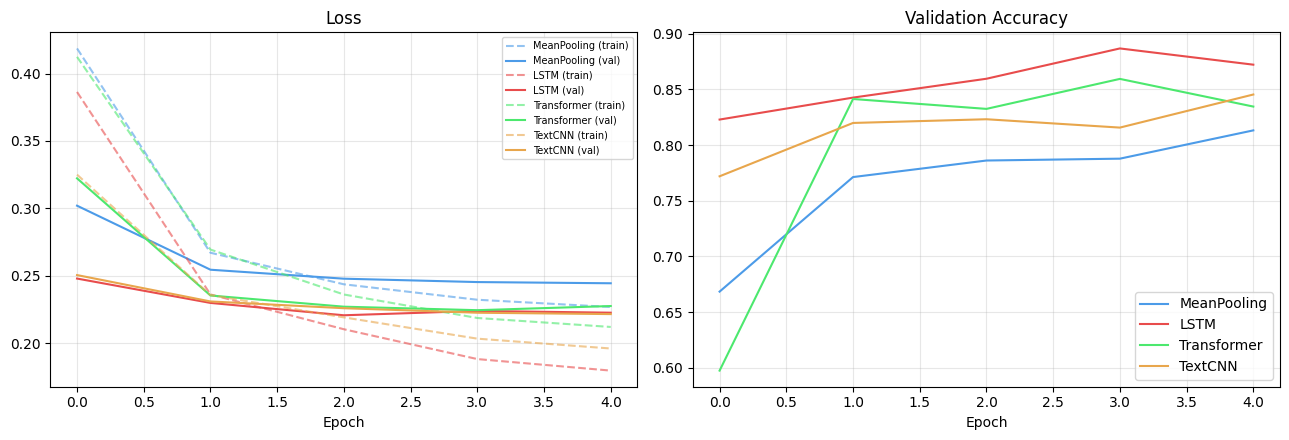

In [23]:
seq_results = train_seq.train_all_seq(
    embedding_matrix, PAD_IDX,
    train_loader, val_loader, test_loader,
    cost_aware=True, epochs=config.EPOCHS,
)
viz.plot_training_curves({n: r["history"] for n, r in seq_results.items()})

In [24]:
rows_seq = [evaluate.evaluate_predictions(
    y_test, r["test_pred"], name=n,
    proba_pos=r["test_proba"][:, 1], verbose=False)
    for n, r in seq_results.items()]
df_seq = evaluate.compare_models(rows_seq, sort_by="total_cost")
print("\n=== 序列模型对比（按 total_cost 升序） ===")
display_cols = ["model", "accuracy", "precision_neg", "recall_neg", "f1_neg",
                "FN", "FP", "total_cost", "best_threshold", "total_cost@best_thr"]
print(df_seq[display_cols].to_string(index=False))
df_seq.to_csv(config.LOG_DIR / "seq_models_compare.csv", index=False)


=== 序列模型对比（按 total_cost 升序） ===
      model  accuracy  precision_neg  recall_neg   f1_neg  FN   FP  total_cost  best_threshold  total_cost@best_thr
Transformer  0.865875       0.801690     0.97225 0.878771 111  962      1517.0            0.55               1511.0
       LSTM  0.862875       0.798110     0.97150 0.876311 114  983      1553.0            0.45               1552.0
    TextCNN  0.847875       0.776585     0.97675 0.865242  93 1124      1589.0            0.50               1590.0
MeanPooling  0.812625       0.736255     0.97425 0.838696 103 1396      1911.0            0.55               1861.0


## §7 任务 1 — 代价矩阵汇总 + 阈值寻优

把经典 + 序列共 14 行评测放在一起按 `total_cost@best_thr` 升序排序；并把"F1 调参"和"cost 调参"两个 Optuna 路径同时放进去，直观看出两条路径在最终 cost 上的差距。


=== Task 1 总结：所有模型按 total_cost@best_thr 升序 ===
   cost matrix: FN=5.0, FP=1.0  (Elkan 2001)
                   model  accuracy   f1_neg  recall_neg  FN   FP  total_cost  best_threshold  total_cost@best_thr
             Transformer  0.865875 0.878771     0.97225 111  962      1517.0            0.55               1511.0
                    LSTM  0.862875 0.876311     0.97150 114  983      1553.0            0.45               1552.0
                 TextCNN  0.847875 0.865242     0.97675  93 1124      1589.0            0.50               1590.0
             MeanPooling  0.812625 0.838696     0.97425 103 1396      1911.0            0.55               1861.0
LogisticRegression__cost  0.817875 0.842401     0.97350 106 1351      1881.0            0.55               1867.0
         LinearSVM__cost  0.877375 0.878724     0.88850 446  535      2765.0            0.20               1891.0
           LinearSVM__f1  0.876500 0.877662     0.88600 456  532      2812.0            0.20               19

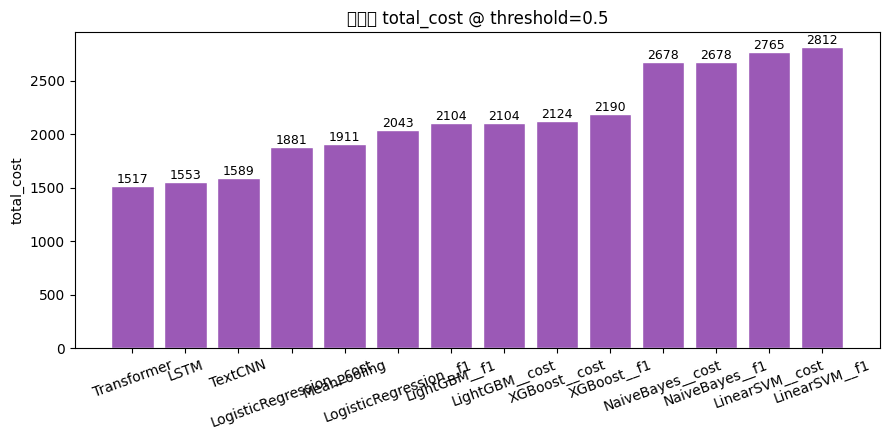

  fig -> /root/autodl-tmp/5.12/outputs/figures/cost_at_optimal_threshold.png


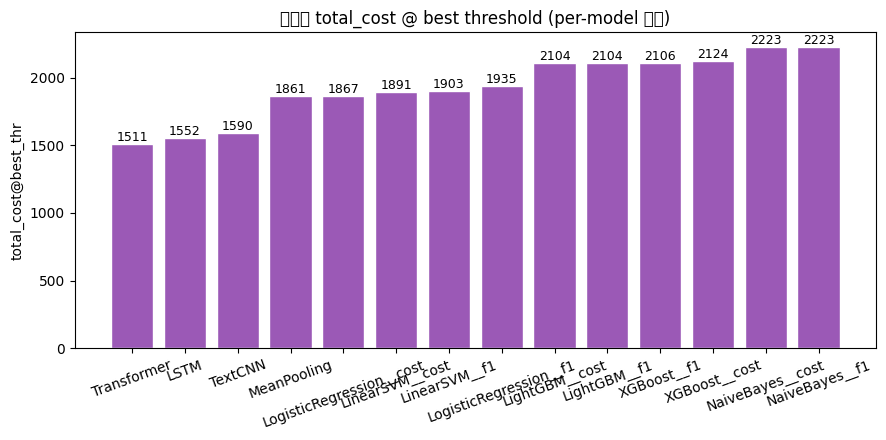

In [25]:
all_rows = rows_f1 + rows_cost + rows_seq
df_all = evaluate.compare_models(all_rows, sort_by="total_cost@best_thr")
print(f"\n=== Task 1 总结：所有模型按 total_cost@best_thr 升序 ===")
print(f"   cost matrix: FN={config.COST_FN}, FP={config.COST_FP}  (Elkan 2001)")
display_cols = ["model", "accuracy", "f1_neg", "recall_neg",
                "FN", "FP", "total_cost", "best_threshold", "total_cost@best_thr"]
print(df_all[display_cols].to_string(index=False))
df_all.to_csv(config.LOG_DIR / "all_models_cost_compare.csv", index=False)
viz.plot_cost_comparison(df_all, value_col="total_cost",
                         name="cost_at_default_threshold.png",
                         title="各模型 total_cost @ threshold=0.5")
viz.plot_cost_comparison(df_all, value_col="total_cost@best_thr",
                         name="cost_at_optimal_threshold.png",
                         title="各模型 total_cost @ best threshold (per-model 最优)")

## §8 任务 2 — 5-fold OOF Stacking（4 序列 + 5 经典）

**OOF (Out-Of-Fold) 设计：** 对每个基模型在 train 上做 K=5 fold，每折用 K-1 个 fold 训练、在 hold-out fold 上输出 `P(差评)` —— 拼起来得到 train 上的 OOF 概率（meta 训练特征）；同时对 test 集 K 次预测取平均得到 meta 测试特征。最终 meta-learner = `RandomForestClassifier(class_weight={0:1, 1:5})`（见 `config.STACK_RF_*`）。

> **运行成本提示**：序列模型 OOF = 4 模型 × 5 折 × `EPOCHS` epochs，2% 数据上耗时较多。如果想缩短，可以在 `src/config.py` 把 `K_FOLD` 改成 3 或者把 `EPOCHS` 调小后重新执行本节。

### 8.1 经典模型 OOF

In [26]:
classic_oof_proba_train = {}
classic_oof_proba_test = {}

def _classic_proba_fn(clf, X):
    return train_classic.predict_proba_pos(clf, X)

for name, run in classic_f1.items():
    print(f"\n[OOF] {name}  (best_params from f1-Optuna)")
    params = run["best_params"]
    refit_fn = lambda p, Xt, yt, _n=name: train_classic.fit_classic_model(_n, p, Xt, yt)
    oof_tr, test_avg = ensemble.kfold_oof_classic(
        name=name, refit_fn=refit_fn, proba_fn=_classic_proba_fn,
        params=params, X_train=X_train, y_train=y_train, X_test=X_test,
        n_splits=config.K_FOLD,
    )
    classic_oof_proba_train[name] = oof_tr
    classic_oof_proba_test[name] = test_avg
print("\n经典模型 OOF 完成。")


[OOF] NaiveBayes  (best_params from f1-Optuna)
  [NaiveBayes] fold 1/3 (train=48000 val=24000)
  [NaiveBayes] fold 2/3 (train=48000 val=24000)
  [NaiveBayes] fold 3/3 (train=48000 val=24000)

[OOF] LogisticRegression  (best_params from f1-Optuna)
  [LogisticRegression] fold 1/3 (train=48000 val=24000)
  [LogisticRegression] fold 2/3 (train=48000 val=24000)
  [LogisticRegression] fold 3/3 (train=48000 val=24000)

[OOF] LinearSVM  (best_params from f1-Optuna)
  [LinearSVM] fold 1/3 (train=48000 val=24000)
  [LinearSVM] fold 2/3 (train=48000 val=24000)
  [LinearSVM] fold 3/3 (train=48000 val=24000)

[OOF] LightGBM  (best_params from f1-Optuna)
  [LightGBM] fold 1/3 (train=48000 val=24000)
  [LightGBM] fold 2/3 (train=48000 val=24000)
  [LightGBM] fold 3/3 (train=48000 val=24000)

[OOF] XGBoost  (best_params from f1-Optuna)
  [XGBoost] fold 1/3 (train=48000 val=24000)
  [XGBoost] fold 2/3 (train=48000 val=24000)
  [XGBoost] fold 3/3 (train=48000 val=24000)

经典模型 OOF 完成。


### 8.2 序列模型 OOF

In [27]:
seq_oof_proba_train = {}
seq_oof_proba_test = {}

for name in config.SEQ_MODEL_NAMES:
    print(f"\n[OOF] {name}")

    def _train_one_fold(tr_idx, va_idx, _n=name):
        tr_loader = train_seq.make_loader(
            train_idx_arr[tr_idx], [train_labels[i] for i in tr_idx], shuffle=True)
        va_loader = train_seq.make_loader(
            train_idx_arr[va_idx], [train_labels[i] for i in va_idx])
        te_loader = train_seq.make_loader(test_idx_arr, test_labels)
        res = train_seq.train_one(
            _n, embedding_matrix, PAD_IDX,
            tr_loader, va_loader, te_loader,
            epochs=config.EPOCHS, lr=train_seq.SEQ_LR[_n],
            cost_aware=True, verbose=False,
        )
        return res["val_proba"][:, 1], res["test_proba"][:, 1]

    oof_tr, test_avg = ensemble.kfold_oof_seq(
        name=name, train_one_fn=_train_one_fold,
        indices_train=train_idx_arr, y_train=train_labels,
        indices_test=test_idx_arr, y_test=test_labels,
        n_splits=config.K_FOLD,
    )
    seq_oof_proba_train[name] = oof_tr
    seq_oof_proba_test[name] = test_avg
print("\n序列模型 OOF 完成。")


[OOF] MeanPooling
  [MeanPooling] fold 1/3 (train=48000 val=24000)
  [MeanPooling] fold 2/3 (train=48000 val=24000)
  [MeanPooling] fold 3/3 (train=48000 val=24000)

[OOF] LSTM
  [LSTM] fold 1/3 (train=48000 val=24000)
  [LSTM] fold 2/3 (train=48000 val=24000)
  [LSTM] fold 3/3 (train=48000 val=24000)

[OOF] Transformer
  [Transformer] fold 1/3 (train=48000 val=24000)
  [Transformer] fold 2/3 (train=48000 val=24000)
  [Transformer] fold 3/3 (train=48000 val=24000)

[OOF] TextCNN
  [TextCNN] fold 1/3 (train=48000 val=24000)
  [TextCNN] fold 2/3 (train=48000 val=24000)
  [TextCNN] fold 3/3 (train=48000 val=24000)

序列模型 OOF 完成。


### 8.3 Soft Voting + Stacking

**Stacking 决策阈值**：在训练集 meta 特征上做 **分层留出**（比例见 `config.STACK_THRESHOLD_VAL_FRACTION`，默认与 `VAL_FRACTION` 相同），在留出子集上用 `cost.find_optimal_threshold` 按 **总 cost** 搜索 τ；再在 **全量 meta_train** 上重训 meta-RF，对测试集使用 **`proba >= τ`**（不再固定 0.5）。Soft Voting 仍用 0.5。

meta_train=(72000, 9)  meta_test=(8000, 9)
Stacking τ=0.150 (阈值校准留出集 total_cost=1277.0)

=== Task 2 集成 vs 单模型（基于 OOF 平均），按 total_cost@best_thr 升序 ===
                                 model  accuracy   f1_neg  recall_neg  FN   FP  total_cost  best_threshold  total_cost@best_thr
Stacking (9-model meta-RF, cost_aware)  0.874750 0.886240     0.97575  97  905      1390.0            0.15               1390.0
                   Stacking (seq-only)  0.887750 0.896041     0.96750 130  768      1418.0            0.20               1418.0
              SoftVoting (9-model avg)  0.857375 0.872614     0.97700  92 1049      1509.0            0.50               1509.0
                        LSTM (OOF avg)  0.867500 0.879928     0.97100 116  944      1524.0            0.50               1524.0
                 Transformer (OOF avg)  0.860500 0.874607     0.97300 108 1008      1548.0            0.55               1526.0
                     TextCNN (OOF avg)  0.835500 0.855954     0.97750  90 1226    

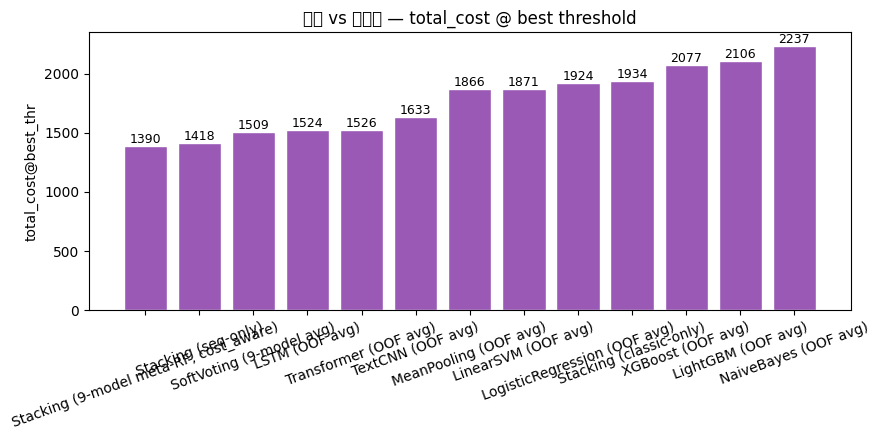

  fig -> /root/autodl-tmp/5.12/outputs/figures/ensemble_recall_neg.png


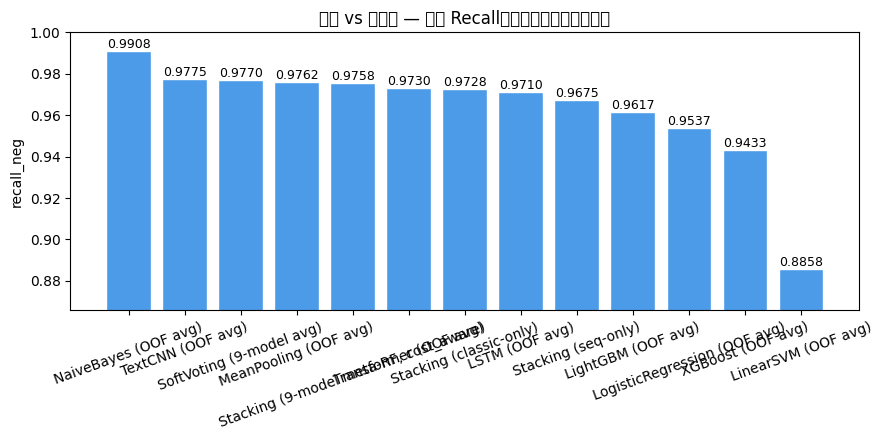

In [28]:
all_train_proba = {**classic_oof_proba_train, **seq_oof_proba_train}
all_test_proba = {**classic_oof_proba_test, **seq_oof_proba_test}
all_names = config.CLASSIC_MODEL_NAMES + config.SEQ_MODEL_NAMES

meta_train = ensemble.build_meta(all_train_proba, all_names)
meta_test = ensemble.build_meta(all_test_proba, all_names)
print(f"meta_train={meta_train.shape}  meta_test={meta_test.shape}")

# Soft Voting：直接把 9 个模型的 P(差评) 取平均
sv_test_proba = np.mean(meta_test, axis=1)
sv_test_pred = (sv_test_proba >= 0.5).astype(int)

# Stacking：成本敏感的 Random Forest meta-learner
stack_clf, stack_tau, stack_thr_val_cost, stack_test_proba = ensemble.fit_stacking_tune_threshold(
    meta_train, y_train, meta_test, cost_aware=True)
stack_test_pred = (stack_test_proba >= stack_tau).astype(int)
print(f"Stacking τ={stack_tau:.3f} (阈值校准留出集 total_cost={stack_thr_val_cost:.1f})")

ens_rows = []
ens_rows.append(evaluate.evaluate_predictions(
    y_test, sv_test_pred, name="SoftVoting (9-model avg)",
    proba_pos=sv_test_proba, verbose=False))
ens_rows.append(evaluate.evaluate_predictions(
    y_test, stack_test_pred, name="Stacking (9-model meta-RF, cost_aware)",
    proba_pos=stack_test_proba, verbose=False, decision_threshold=stack_tau))

# 同时给一个仅序列 / 仅经典的对照
seq_only_meta_test = ensemble.build_meta(seq_oof_proba_test, config.SEQ_MODEL_NAMES)
seq_only_meta_train = ensemble.build_meta(seq_oof_proba_train, config.SEQ_MODEL_NAMES)
seq_stack_clf, seq_stack_tau, seq_stack_thr_val_cost, seq_stack_proba = ensemble.fit_stacking_tune_threshold(
    seq_only_meta_train, y_train, seq_only_meta_test, cost_aware=True)
seq_stack_pred = (seq_stack_proba >= seq_stack_tau).astype(int)

clas_only_meta_test = ensemble.build_meta(classic_oof_proba_test, config.CLASSIC_MODEL_NAMES)
clas_only_meta_train = ensemble.build_meta(classic_oof_proba_train, config.CLASSIC_MODEL_NAMES)
clas_stack_clf, clas_stack_tau, clas_stack_thr_val_cost, clas_stack_proba = ensemble.fit_stacking_tune_threshold(
    clas_only_meta_train, y_train, clas_only_meta_test, cost_aware=True)
clas_stack_pred = (clas_stack_proba >= clas_stack_tau).astype(int)

ens_rows.append(evaluate.evaluate_predictions(
    y_test, seq_stack_pred, name="Stacking (seq-only)",
    proba_pos=seq_stack_proba, verbose=False, decision_threshold=seq_stack_tau))
ens_rows.append(evaluate.evaluate_predictions(
    y_test, clas_stack_pred, name="Stacking (classic-only)",
    proba_pos=clas_stack_proba, verbose=False, decision_threshold=clas_stack_tau))

# 用 OOF 测试概率重算单模型行（与个人评测稍有差异：OOF 是 5 折平均）
single_oof_rows = []
for n in all_names:
    p = all_test_proba[n]
    pr = (p >= 0.5).astype(int)
    single_oof_rows.append(evaluate.evaluate_predictions(
        y_test, pr, name=f"{n} (OOF avg)", proba_pos=p, verbose=False))

df_ensemble = evaluate.compare_models(ens_rows + single_oof_rows,
                                      sort_by="total_cost@best_thr")
print("\n=== Task 2 集成 vs 单模型（基于 OOF 平均），按 total_cost@best_thr 升序 ===")
display_cols = ["model", "accuracy", "f1_neg", "recall_neg",
                "FN", "FP", "total_cost",
                "best_threshold", "total_cost@best_thr"]
print(df_ensemble[display_cols].to_string(index=False))
df_ensemble.to_csv(config.LOG_DIR / "ensemble_vs_single.csv", index=False)
viz.plot_cost_comparison(df_ensemble, value_col="total_cost@best_thr",
                         name="ensemble_cost.png",
                         title="集成 vs 单模型 — total_cost @ best threshold")
viz.plot_metric_comparison(df_ensemble, value_col="recall_neg",
                           name="ensemble_recall_neg.png",
                           title="集成 vs 单模型 — 差评 Recall（越高越好，不漏差评）")

In [29]:
# 看一眼 stacking meta-RF 学到了什么（每个基模型的特征重要性）
imp_vals, _ = ensemble.meta_learner_contributions(stack_clf, all_names)
coef = pd.DataFrame({
    "feature": all_names,
    "importance": imp_vals,
}).sort_values("importance", ascending=False)
print("Stacking meta-RF 特征重要性（越大 → 对集成预测影响越强）：")
print(coef.to_string(index=False))

Stacking meta-RF 特征重要性（越大 → 对集成预测影响越强）：
           feature  importance
       Transformer    0.271093
              LSTM    0.194398
           TextCNN    0.184026
       MeanPooling    0.095610
         LinearSVM    0.087585
LogisticRegression    0.062210
        NaiveBayes    0.036243
          LightGBM    0.035809
           XGBoost    0.033025


## §9 错误分析（高置信度错判 / 模型分歧 / 语言现象）

为了与 §10 的 LLM 输入对齐，本节统一基于 §8.3 训练好的 9-模型 Stacking 输出。

In [30]:
preds_dict = {n: (all_test_proba[n] >= 0.5).astype(int) for n in all_names}
preds_dict["Stacking"] = stack_test_pred
proba_dict = dict(all_test_proba)
proba_dict["Stacking"] = stack_test_proba

# 9.1 高置信度错判 (基于 Stacking)
hc = error_analysis.high_confidence_errors(
    test_texts, y_test, stack_test_pred, stack_test_proba,
    threshold=config.HIGH_CONF_THRESHOLD, top_n=20,
)
print(f"\nStacking 高置信度（≥{config.HIGH_CONF_THRESHOLD}）错判 Top {len(hc)}：")
for _, row in hc.iterrows():
    txt = row["text"].replace("\n", " ")
    print(f"  [conf={row['confidence']:.3f}] true={row['true_name']} "
          f"pred={row['pred_name']}  {txt[:200]}")
hc.to_csv(config.LOG_DIR / "stacking_high_conf_errors.csv", index=False)


Stacking 高置信度（≥0.9）错判 Top 20：
  [conf=1.000] true=差评(1) pred=好评(0)  an oldie movie: Saw it when I was a kid with my mom....it was funnier when i was a kid. Ended up giving the movie to my mom and she loves it.
  [conf=1.000] true=差评(1) pred=好评(0)  Degunking Windows: Another great book by Joli Ballew- This book, along with her past efforts is easy to follow and full of hints for both I.T. professionals and home users alike.The 'plain English' ap
  [conf=1.000] true=差评(1) pred=好评(0)  Banville beats you in the head with his vocabulary: Yes, it's beautifully written prose. Each sentence crafted by an artist. I suppose that's the fuel behind its winning the Man Booker prize. But can 
  [conf=1.000] true=差评(1) pred=好评(0)  Great Read for Auburn Lovers: If you love Auburn, particularly Auburn Football, this book is for you. Rob gives you the positive inside view of a great tradition as told by a young man with great tale
  [conf=1.000] true=好评(0) pred=差评(1)  decent mount... horrible screws: T

In [31]:
# 9.2 模型分歧 — 9 个基模型 + Stacking 是否一致
all_preds_for_dis = dict(preds_dict)  # 已含 Stacking
diss = error_analysis.model_disagreement(all_preds_for_dis, y_test)
print(f"全部正确: {int(diss['all_correct_mask'].sum())}")
print(f"全部错误（含 Stacking）: {int(diss['all_wrong_mask'].sum())}  ← 任务 3 输入 (A)")
print(f"过半错误:        {int(diss['majority_wrong_mask'].sum())}")

全部正确: 4638
全部错误（含 Stacking）: 331  ← 任务 3 输入 (A)
过半错误:        1242


## 9.2b 错误样本全量导出

写入 `outputs/logs/`：`stacking_errors_all.csv`（Stacking 全部错判）、`stacking_high_conf_errors_all.csv`（高置信错判全表）、`dispute_all_models_wrong.csv`（九模型+Stacking 全错）、`dispute_majority_wrong.csv`（过半错），以及 `stacking_high_conf_errors_top200.csv` 便于抽查。便于自喂大模型或人工复核。

In [32]:
error_analysis.export_error_sample_corpus(
    test_texts, y_test, preds_dict,
    stack_pred=stack_test_pred,
    stack_proba=stack_test_proba,
    log_dir=config.LOG_DIR,
    high_conf_top_n=200,
)

[error-export] wrote:
  stacking_errors_all.csv: 1002 rows -> /root/autodl-tmp/5.12/outputs/logs/stacking_errors_all.csv
  stacking_high_conf_errors_all.csv: 135 rows -> /root/autodl-tmp/5.12/outputs/logs/stacking_high_conf_errors_all.csv
  stacking_high_conf_errors_top200.csv: 135 rows -> /root/autodl-tmp/5.12/outputs/logs/stacking_high_conf_errors_top200.csv
  dispute_all_models_wrong.csv: 331 rows -> /root/autodl-tmp/5.12/outputs/logs/dispute_all_models_wrong.csv
  dispute_majority_wrong.csv: 1242 rows -> /root/autodl-tmp/5.12/outputs/logs/dispute_majority_wrong.csv


{'stacking_errors_all': PosixPath('/root/autodl-tmp/5.12/outputs/logs/stacking_errors_all.csv'),
 'stacking_high_conf_errors_all': PosixPath('/root/autodl-tmp/5.12/outputs/logs/stacking_high_conf_errors_all.csv'),
 'stacking_high_conf_errors_top': PosixPath('/root/autodl-tmp/5.12/outputs/logs/stacking_high_conf_errors_top200.csv'),
 'dispute_all_models_wrong': PosixPath('/root/autodl-tmp/5.12/outputs/logs/dispute_all_models_wrong.csv'),
 'dispute_majority_wrong': PosixPath('/root/autodl-tmp/5.12/outputs/logs/dispute_majority_wrong.csv')}


[语言现象 — Stacking 错判 vs 正确]
             错判样本(%)  正确样本(%)  差值(错-对)
negation       58.28    56.22     2.06
adversative    60.98    46.60    14.38
exclam         31.94    33.18    -1.24
question       12.77    10.76     2.01
all_caps       26.25    27.45    -1.20
  fig -> /root/autodl-tmp/5.12/outputs/figures/error_linguistic_stats.png


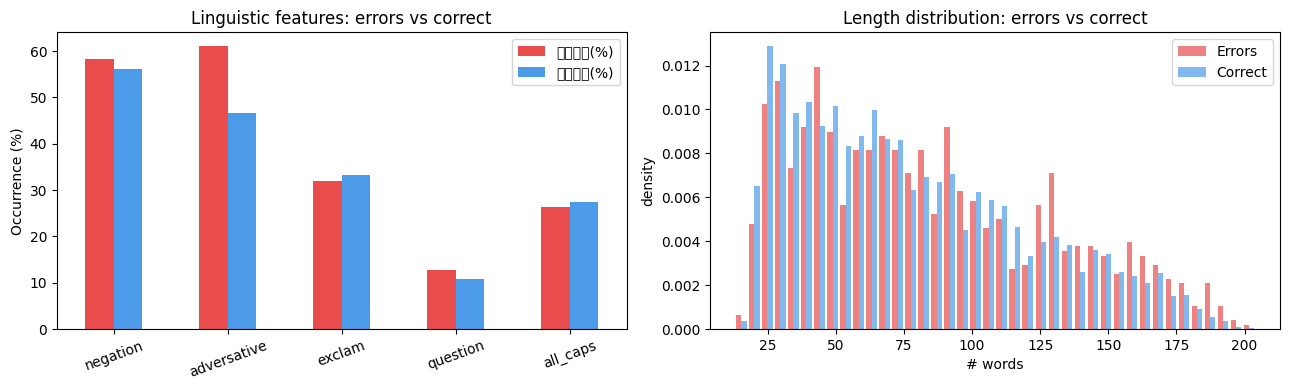

In [33]:
# 9.3 语言现象统计（基于 Stacking 的错判 vs 正确）
err_mask = preds_dict["Stacking"] != y_test
stats_df, err_feats, correct_feats = error_analysis.error_linguistic_stats(test_texts, err_mask)
print("\n[语言现象 — Stacking 错判 vs 正确]")
print(stats_df)
viz.plot_linguistic_stats(stats_df, err_feats["len"].values, correct_feats["len"].values)
stats_df.to_csv(config.LOG_DIR / "stacking_linguistic_stats.csv")

## §10 任务 3 — LLM 错误分析（多后端，stub 默认演示）

**送入 LLM 的两类争议样本：**

- **(A) 集成全错**：9 个基模型 + Stacking 全部预测错的样本（最强烈的"标注错误 / 语义矛盾"嫌疑）。
- **(B) 高置信度错判**：Stacking 错判且置信度 ≥ 0.9 的 Top N（最具研究价值的"模型自信地错"）。

**LLM 后端：** 默认 `stub`（基于 VADER 的兜底，便于无 key 时跑通管道）。要换成真实 API：

```python
import os
os.environ["LLM_BACKEND"] = "openai"   # 或 anthropic / ollama
os.environ["OPENAI_API_KEY"] = "sk-..."
```

随后重启 kernel 或 `from src.llm_providers import get_provider; provider = get_provider()` 即可。

In [34]:
from src.llm_providers import get_provider

# 选样
all_wrong_idx = llm_judge.select_all_wrong(
    y_test, base_preds=preds_dict, ensemble_pred=stack_test_pred,
)
high_conf_idx = llm_judge.select_high_conf_wrong(
    y_test, stack_test_pred, stack_test_proba,
    threshold=config.HIGH_CONF_THRESHOLD,
    top_n=config.LLM_DEMO_N_HIGH_CONF,
)
print(f"集成全错 总数={len(all_wrong_idx)}；本次 demo 取 N={min(len(all_wrong_idx), config.LLM_DEMO_N_ALL_WRONG)}")
print(f"高置信度错判 (≥{config.HIGH_CONF_THRESHOLD}) demo N={len(high_conf_idx)}")

provider = get_provider()
print(f"\n使用 LLM 后端: backend={provider.backend}  model={provider.model}")

集成全错 总数=331；本次 demo 取 N=20
高置信度错判 (≥0.9) demo N=20

使用 LLM 后端: backend=stub  model=vader-heuristic


In [35]:
records_a = llm_judge.judge_samples(
    indices=all_wrong_idx[:config.LLM_DEMO_N_ALL_WRONG],
    texts=test_texts, y_true=y_test,
    model_pred=stack_test_pred, proba_pos=stack_test_proba,
    bucket="all_wrong",
    provider=provider,
)
records_b = llm_judge.judge_samples(
    indices=high_conf_idx,
    texts=test_texts, y_true=y_test,
    model_pred=stack_test_pred, proba_pos=stack_test_proba,
    bucket="high_conf_wrong",
    provider=provider,
)
all_records = records_a + records_b

llm_judge.save_records(all_records,
                       jsonl_path=config.LLM_DIR / "raw_responses.jsonl",
                       csv_path=config.LLM_DIR / "summary.csv")
stats_df = llm_judge.aggregate_stats(all_records)
stats_df.to_csv(config.LLM_DIR / "agreement_stats.csv", index=False)
print("\n=== LLM ↔ Model / LLM ↔ Truth 一致率 ===")
print(stats_df.to_string(index=False))

[llm-judge] backend=stub model=vader-heuristic bucket=all_wrong N=20
  [all_wrong] 5/20 done
  [all_wrong] 10/20 done
  [all_wrong] 15/20 done
  [all_wrong] 20/20 done
[llm-judge] backend=stub model=vader-heuristic bucket=high_conf_wrong N=20
  [high_conf_wrong] 5/20 done
  [high_conf_wrong] 10/20 done
  [high_conf_wrong] 15/20 done
  [high_conf_wrong] 20/20 done
  saved -> /root/autodl-tmp/5.12/outputs/llm_judgments/raw_responses.jsonl  +  /root/autodl-tmp/5.12/outputs/llm_judgments/summary.csv  (40 rows)

=== LLM ↔ Model / LLM ↔ Truth 一致率 ===
         bucket  n_total  n_valid_response  valid_rate  agree_with_model_rate  agree_with_truth_rate  suspected_label_error_rate  n_suspected_label_error
      all_wrong       20                20         1.0                   0.25                   0.75                        0.25                        5
high_conf_wrong       20                20         1.0                   0.80                   0.20                        0.80             

In [36]:
# 展示前 5 条 A 桶 + 前 5 条 B 桶的判定细节
def _show(records, title, n=5):
    print("\n" + "=" * 72)
    print(f" {title}  (展示前 {min(n, len(records))} 条)")
    print("=" * 72)
    for r in records[:n]:
        text = r["text"].replace("\n", " ")
        flag = "★ 疑似标注错误" if r["suspected_label_error"] else ""
        print(f"\n[idx={r['idx']}] true={r['true_label_name']}  "
              f"model={r['model_pred_name']} (conf={r['model_confidence']:.3f})  "
              f"llm={r['llm_label_name']} (conf={r['llm_confidence']:.2f}) {flag}")
        print(f"  rationale: {r['llm_rationale']}")
        print(f"  text     : {text[:300]}")

_show(records_a, "(A) 集成全错")
_show(records_b, "(B) Stacking 高置信度错判")


 (A) 集成全错  (展示前 5 条)

[idx=40] true=好评(0)  model=差评(1) (conf=0.950)  llm=好评(0) (conf=1.00) 
  rationale: VADER: 整体正向评分占优
  text     : The Fall of Reach: This book is very good. The story line is fantastic and I cannot put it down. There is one problem, however. This book was very poorly proofread if proofread at all. There are many grammatical mistakes and other errors that middle school students could eliminate if they had read t

[idx=53] true=好评(0)  model=差评(1) (conf=0.985)  llm=好评(0) (conf=0.77) 
  rationale: VADER: 整体正向评分占优
  text     : typos galore!: I do not intend to review content here. This new edition is so full of typographical errors that sometimes the reader will have to intuit what the author really wrote. It is clear that the proofreaders of this edition were not actually reading; they were simply following the little re

[idx=87] true=好评(0)  model=差评(1) (conf=0.690)  llm=好评(0) (conf=1.00) 
  rationale: VADER: 整体正向评分占优
  text     : Doing the Evolution: In some respects

## §11 最终汇总

按 `total_cost@best_thr` 升序汇总：5 经典 (×2 Optuna 目标) + 4 序列 + Soft Voting + Stacking 全集 + 仅序列 / 仅经典 Stacking。

In [37]:
final_rows = (rows_f1 + rows_cost + rows_seq + ens_rows)
df_final = evaluate.compare_models(final_rows, sort_by="total_cost@best_thr")
display_cols = ["model", "accuracy", "f1_neg", "recall_neg",
                "FN", "FP", "total_cost",
                "best_threshold", "total_cost@best_thr"]
print("=" * 90)
print(" 最终汇总（按 total_cost @ best threshold 升序，越低越好）")
print("=" * 90)
print(df_final[display_cols].to_string(index=False))
df_final.to_csv(config.LOG_DIR / "final_summary.csv", index=False)

best_row = df_final.iloc[0]
print(f"\n>>> 最优方案: {best_row['model']}")
print(f"    accuracy={best_row['accuracy']:.4f}  f1_neg={best_row['f1_neg']:.4f}  "
      f"recall_neg={best_row['recall_neg']:.4f}")
print(f"    FN={int(best_row['FN'])}  FP={int(best_row['FP'])}  "
      f"total_cost@best_thr={best_row['total_cost@best_thr']:.0f}  "
      f"@thr={best_row['best_threshold']:.2f}")

 最终汇总（按 total_cost @ best threshold 升序，越低越好）
                                 model  accuracy   f1_neg  recall_neg  FN   FP  total_cost  best_threshold  total_cost@best_thr
Stacking (9-model meta-RF, cost_aware)  0.874750 0.886240     0.97575  97  905      1390.0            0.15               1390.0
                   Stacking (seq-only)  0.887750 0.896041     0.96750 130  768      1418.0            0.20               1418.0
              SoftVoting (9-model avg)  0.857375 0.872614     0.97700  92 1049      1509.0            0.50               1509.0
                           Transformer  0.865875 0.878771     0.97225 111  962      1517.0            0.55               1511.0
                                  LSTM  0.862875 0.876311     0.97150 114  983      1553.0            0.45               1552.0
                               TextCNN  0.847875 0.865242     0.97675  93 1124      1589.0            0.50               1590.0
                           MeanPooling  0.812625 0.838696  

---

### 三大任务交付物清单

| 任务 | 输出文件 |
| --- | --- |
| Task 1 代价矩阵 | `outputs/logs/classic_models_compare.csv`、`outputs/logs/seq_models_compare.csv`、`outputs/logs/all_models_cost_compare.csv`、`outputs/figures/cost_at_default_threshold.png`、`outputs/figures/cost_at_optimal_threshold.png` |
| Task 2 集成学习 | `outputs/logs/ensemble_vs_single.csv`、`outputs/figures/ensemble_cost.png`、`outputs/figures/ensemble_recall_neg.png` |
| Task 3 LLM 错误分析 | `outputs/llm_judgments/raw_responses.jsonl`、`outputs/llm_judgments/summary.csv`、`outputs/llm_judgments/agreement_stats.csv` |